<a href="https://colab.research.google.com/github/Zaman-SE/Machine-Learning/blob/main/Gradient_Boosting_Machines_(GBMs)_with_XGBoost_and_LightGBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Installing the required libraries

In [53]:
!pip install numpy pandas matplotlib plotly seaborn --quiet

In [54]:
!pip install jovian opendatasets xgboost graphviz lightgbm scikit-learn xgboost --upgrade

In [55]:
import os
import opendatasets as od
import pandas as pd
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

In [56]:
od.download('https://www.kaggle.com/c/rossmann-store-sales')

Skipping, found downloaded files in "./rossmann-store-sales" (use force=True to force download)


## Load Data

In [57]:
os.listdir('rossmann-store-sales')

['store.csv', 'sample_submission.csv', 'train.csv', 'test.csv']

In [58]:
ross_df = pd.read_csv('/content/rossmann-store-sales/train.csv', low_memory=False)
store_df = pd.read_csv('/content/rossmann-store-sales/store.csv')
test_df = pd.read_csv('/content/rossmann-store-sales/test.csv')
submission_df = pd.read_csv('/content/rossmann-store-sales/sample_submission.csv')

In [59]:
ross_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


In [60]:
test_df

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0
...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1.0,0,0,0
41084,41085,1112,6,2015-08-01,1.0,0,0,0
41085,41086,1113,6,2015-08-01,1.0,0,0,0
41086,41087,1114,6,2015-08-01,1.0,0,0,0


In [61]:
store_df

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [62]:
submission_df

,Id,Sales
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0
...,...,...
41083,41084,0
41084,41085,0
41085,41086,0
41086,41087,0


In [63]:
merged_df = ross_df.merge(store_df, how='left', on='Store')
merged_test_df = test_df.merge(store_df, how='left', on='Store')

In [64]:
merged_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [65]:
merged_test_df

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,1,4,2015-09-17,1.0,1,0,0,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,3,4,2015-09-17,1.0,1,0,0,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
2,3,7,4,2015-09-17,1.0,1,0,0,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
3,4,8,4,2015-09-17,1.0,1,0,0,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
4,5,9,4,2015-09-17,1.0,1,0,0,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1.0,0,0,0,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
41084,41085,1112,6,2015-08-01,1.0,0,0,0,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
41085,41086,1113,6,2015-08-01,1.0,0,0,0,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
41086,41087,1114,6,2015-08-01,1.0,0,0,0,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [66]:
merged_df['Date'].dtype

dtype('O')

# Preprocessing and Feature Engineering

# Date
convert Date to datecolumn and extract different parts

In [67]:
def split_date(df):
  df['Date'] = pd.to_datetime(df['Date'])
  df['Year'] = df['Date'].dt.year
  df['Month'] = df['Date'].dt.month
  df['Day'] = df['Date'].dt.day
  df['WeekOfYear'] = df.Date.dt.isocalendar().week

In [68]:
split_date(merged_df)
split_date(merged_test_df)

In [69]:
merged_df['Date'].dtype

dtype('<M8[ns]')

# Store open or closed

In [70]:
merged_df[merged_df.Open == 0].Sales.value_counts()

,count
Sales,
0,172817


In [71]:
merged_df = merged_df[merged_df.Open == 1].copy()

# Competition months

In [72]:
def competition_months(df):
  df['CompetitionOpenInMonth'] = 12 * (df.Year - df.CompetitionOpenSinceYear) + (df.Month - df.CompetitionOpenSinceMonth)
  df['CompetitionOpenInMonth'] = df['CompetitionOpenInMonth'].apply(lambda x: 0 if x < 0 else x).fillna(0)

In [73]:
competition_months(merged_df)
competition_months(merged_test_df)

In [74]:
merged_df[['Date', 'CompetitionDistance', 'CompetitionOpenSinceYear', 'CompetitionOpenSinceMonth', 'CompetitionOpenInMonth']]

,Date,CompetitionDistance,CompetitionOpenSinceYear,CompetitionOpenSinceMonth,CompetitionOpenInMonth
0,2015-07-31,1270.0,2008.0,9.0,82.0
1,2015-07-31,570.0,2007.0,11.0,92.0
2,2015-07-31,14130.0,2006.0,12.0,103.0
3,2015-07-31,620.0,2009.0,9.0,70.0
4,2015-07-31,29910.0,2015.0,4.0,3.0
...,...,...,...,...,...
1016776,2013-01-01,150.0,2006.0,9.0,76.0
1016827,2013-01-01,860.0,1999.0,10.0,159.0
1016863,2013-01-01,840.0,NaN,NaN,0.0
1017042,2013-01-01,1430.0,NaN,NaN,0.0


# Additional Promotoion

In [75]:
def check_promo_month(row):
  month2str = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9: 'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
  try:
    months = (row['PromoInterval'] or '').split(',')
    if row['Promo2Open'] and month2str[row['Month']] in months:
      return 1
    else:
      return 0
  except Exception:
    return 0
def promo_cols(df):
  #months since promo2 was open
  df['Promo2Open'] = 12 * (df.Year - df.Promo2SinceYear) + (df.WeekOfYear - df.Promo2SinceWeek)
  df['Promo2Open'] = df['Promo2Open'].map(lambda x: 0 if x < 0 else x).fillna(0) * df['Promo2']
  #whether a new round of promotions was started in the current month
  df['IsPromo2Month'] = df.apply(check_promo_month, axis=1) * df['Promo2']


In [83]:
promo_cols(merged_df)
promo_cols(merged_test_df)

# Select column that we will use for training

In [84]:
merged_df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval', 'Year', 'Month', 'Day',
       'WeekOfYear', 'CompetitionOpenInMonth', 'Promo2Open', 'IsPromo2Month'],
      dtype='object')

In [85]:
input_cols = ['Store', 'DayOfWeek', 'Promo', 'StateHoliday', 'SchoolHoliday',
              'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenInMonth', 'Day', 'Month', 'Year', 'WeekOfYear', 'Promo2', 'Promo2Open', 'IsPromo2Month']
target_col = 'Sales'

In [86]:
inputs = merged_df[input_cols].copy()
targets = merged_df[target_col].copy()

In [87]:
inputs

,Store,DayOfWeek,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenInMonth,Day,Month,Year,WeekOfYear,Promo2,Promo2Open,IsPromo2Month
0,1,5,1,0,1,c,a,1270.0,82.0,31,7,2015,31,0,0.0,0
1,2,5,1,0,1,a,a,570.0,92.0,31,7,2015,31,1,78.0,1
2,3,5,1,0,1,a,a,14130.0,103.0,31,7,2015,31,1,65.0,1
3,4,5,1,0,1,c,c,620.0,70.0,31,7,2015,31,0,0.0,0
4,5,5,1,0,1,a,a,29910.0,3.0,31,7,2015,31,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,682,2,0,a,1,b,a,150.0,76.0,1,1,2013,1,0,0.0,0
1016827,733,2,0,a,1,b,b,860.0,159.0,1,1,2013,1,0,0.0,0
1016863,769,2,0,a,1,b,b,840.0,0.0,1,1,2013,1,1,0.0,0
1017042,948,2,0,a,1,b,b,1430.0,0.0,1,1,2013,1,0,0.0,0


In [88]:
targets

,Sales
0,5263
1,6064
2,8314
3,13995
4,4822
...,...
1016776,3375
1016827,10765
1016863,5035
1017042,4491


In [89]:
test_inputs = merged_test_df[input_cols].copy()

In [92]:
test_inputs

,Store,DayOfWeek,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenInMonth,Day,Month,Year,WeekOfYear,Promo2,Promo2Open,IsPromo2Month
0,1,4,1,0,0,c,a,1270.0,84.0,17,9,2015,38,0,0.0,0
1,3,4,1,0,0,a,a,14130.0,105.0,17,9,2015,38,1,72.0,0
2,7,4,1,0,0,a,c,24000.0,29.0,17,9,2015,38,0,0.0,0
3,8,4,1,0,0,a,a,7520.0,11.0,17,9,2015,38,0,0.0,0
4,9,4,1,0,0,a,c,2030.0,181.0,17,9,2015,38,0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41083,1111,6,0,0,0,a,a,1900.0,14.0,1,8,2015,31,1,24.0,0
41084,1112,6,0,0,0,c,c,1880.0,112.0,1,8,2015,31,0,0.0,0
41085,1113,6,0,0,0,a,c,9260.0,0.0,1,8,2015,31,0,0.0,0
41086,1114,6,0,0,0,a,c,870.0,0.0,1,8,2015,31,0,0.0,0


Identify numeric and categorical columns.

In [90]:
numeric_cols = ['Store', 'Promo', 'SchoolHoliday', 'Year', 'Month', 'Day', 'WeekOfYear',
              'CompetitionDistance', 'CompetitionOpenInMonth']
categorical_cols = ['DayOfWeek', 'StateHoliday', 'StoreType', 'Assortment' ]

In [91]:
merged_df[['Date', 'Promo2', 'Promo2SinceYear', 'Promo2SinceWeek', 'PromoInterval', 'Promo2Open', 'IsPromo2Month']].sample(20)

,Date,Promo2,Promo2SinceYear,Promo2SinceWeek,PromoInterval,Promo2Open,IsPromo2Month
506125,2014-04-04,1,2011.0,14.0,"Jan,Apr,Jul,Oct",36.0,1
486213,2014-04-22,0,NaN,NaN,NaN,0.0,0
668711,2013-11-09,0,NaN,NaN,NaN,0.0,0
484246,2014-04-23,0,NaN,NaN,NaN,0.0,0
842697,2013-06-06,0,NaN,NaN,NaN,0.0,0
732984,2013-09-12,0,NaN,NaN,NaN,0.0,0
92568,2015-05-09,1,2011.0,40.0,"Jan,Apr,Jul,Oct",27.0,0
827313,2013-06-20,1,2012.0,48.0,"Jan,Apr,Jul,Oct",0.0,0
524632,2014-03-18,1,2013.0,5.0,"Feb,May,Aug,Nov",19.0,0
821490,2013-06-25,1,2011.0,48.0,"Mar,Jun,Sept,Dec",2.0,1


Impute missing numerical data

In [93]:
inputs[numeric_cols].isna().sum()

,0
Store,0
Promo,0
SchoolHoliday,0
Year,0
Month,0
Day,0
WeekOfYear,0
CompetitionDistance,2186
CompetitionOpenInMonth,0


In [94]:
test_inputs[numeric_cols].isna().sum()

,0
Store,0
Promo,0
SchoolHoliday,0
Year,0
Month,0
Day,0
WeekOfYear,0
CompetitionDistance,96
CompetitionOpenInMonth,0


Fill the CompetitionDistance missing values with the highest value

In [95]:
max_distance = inputs.CompetitionDistance.max()

In [97]:
inputs['CompetitionDistance'].fillna(max_distance*2, inplace=True)
test_inputs['CompetitionDistance'].fillna(max_distance*2, inplace=True)

/tmp/ipython-input-733699737.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  inputs['CompetitionDistance'].fillna(max_distance*2, inplace=True)
/tmp/ipython-input-733699737.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

## Scale Numeric values
scale numeric values to the 0 to 1 range

In [98]:
from sklearn.preprocessing import MinMaxScaler

In [99]:
scaler = MinMaxScaler().fit(inputs[numeric_cols])

In [100]:
inputs[numeric_cols] = scaler.transform(inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])

one hot encode categorical columns

In [102]:
from sklearn.preprocessing import OneHotEncoder

In [104]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(inputs[categorical_cols])
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))

In [105]:
inputs[encoded_cols] = encoder.transform(inputs[categorical_cols])
test_inputs[encoded_cols] = encoder.transform(test_inputs[categorical_cols])


extract out all the numeric data for training

In [106]:
X = inputs[numeric_cols + encoded_cols]
X_test = test_inputs[numeric_cols + encoded_cols]

In [107]:
X

,Store,Promo,SchoolHoliday,Year,Month,Day,WeekOfYear,CompetitionDistance,CompetitionOpenInMonth,DayOfWeek_1,DayOfWeek_2,DayOfWeek_3,DayOfWeek_4,DayOfWeek_5,DayOfWeek_6,DayOfWeek_7,StateHoliday_0,StateHoliday_a,StateHoliday_b,StateHoliday_c,StoreType_a,StoreType_b,StoreType_c,StoreType_d,Assortment_a,Assortment_b,Assortment_c
0,0.000000,1.0,1.0,1.0,0.545455,1.0,0.588235,0.016482,0.059163,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,0.000898,1.0,1.0,1.0,0.545455,1.0,0.588235,0.007252,0.066378,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.001795,1.0,1.0,1.0,0.545455,1.0,0.588235,0.186050,0.074315,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.002693,1.0,1.0,1.0,0.545455,1.0,0.588235,0.007911,0.050505,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.003591,1.0,1.0,1.0,0.545455,1.0,0.588235,0.394119,0.002165,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016776,0.611311,0.0,1.0,0.0,0.000000,0.0,0.000000,0.001714,0.054834,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1016827,0.657092,0.0,1.0,0.0,0.000000,0.0,0.000000,0.011076,0.114719,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1016863,0.689408,0.0,1.0,0.0,0.000000,0.0,0.000000,0.010812,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1017042,0.850090,0.0,1.0,0.0,0.000000,0.0,0.000000,0.018592,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


## Training

In [110]:
from xgboost import XGBRegressor

In [112]:
?XGBRegressor

In [113]:
model = XGBRegressor(random_state=42,n_jobs=-1, n_estimators=20, max_depth=4)

In [114]:
model.fit(X, targets)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

## Prediction

In [115]:
preds = model.predict(X)

In [116]:
preds

array([7587.6714, 7587.6714, 8329.603 , ..., 8704.807 , 6962.7715,
       8657.075 ], dtype=float32)

## Evaluation

In [119]:
from sklearn.metrics import root_mean_squared_error
def rmse(a, b):
  return root_mean_squared_error(a, b)

In [121]:
rmse(preds, targets)

2418.008056640625

## Visualization

In [122]:
import matplotlib.pyplot as plt
from xgboost import plot_tree
from matplotlib.pylab import rcParams
%matplotlib inline

rcParams['figure.figsize'] = 30, 30

<Axes: >

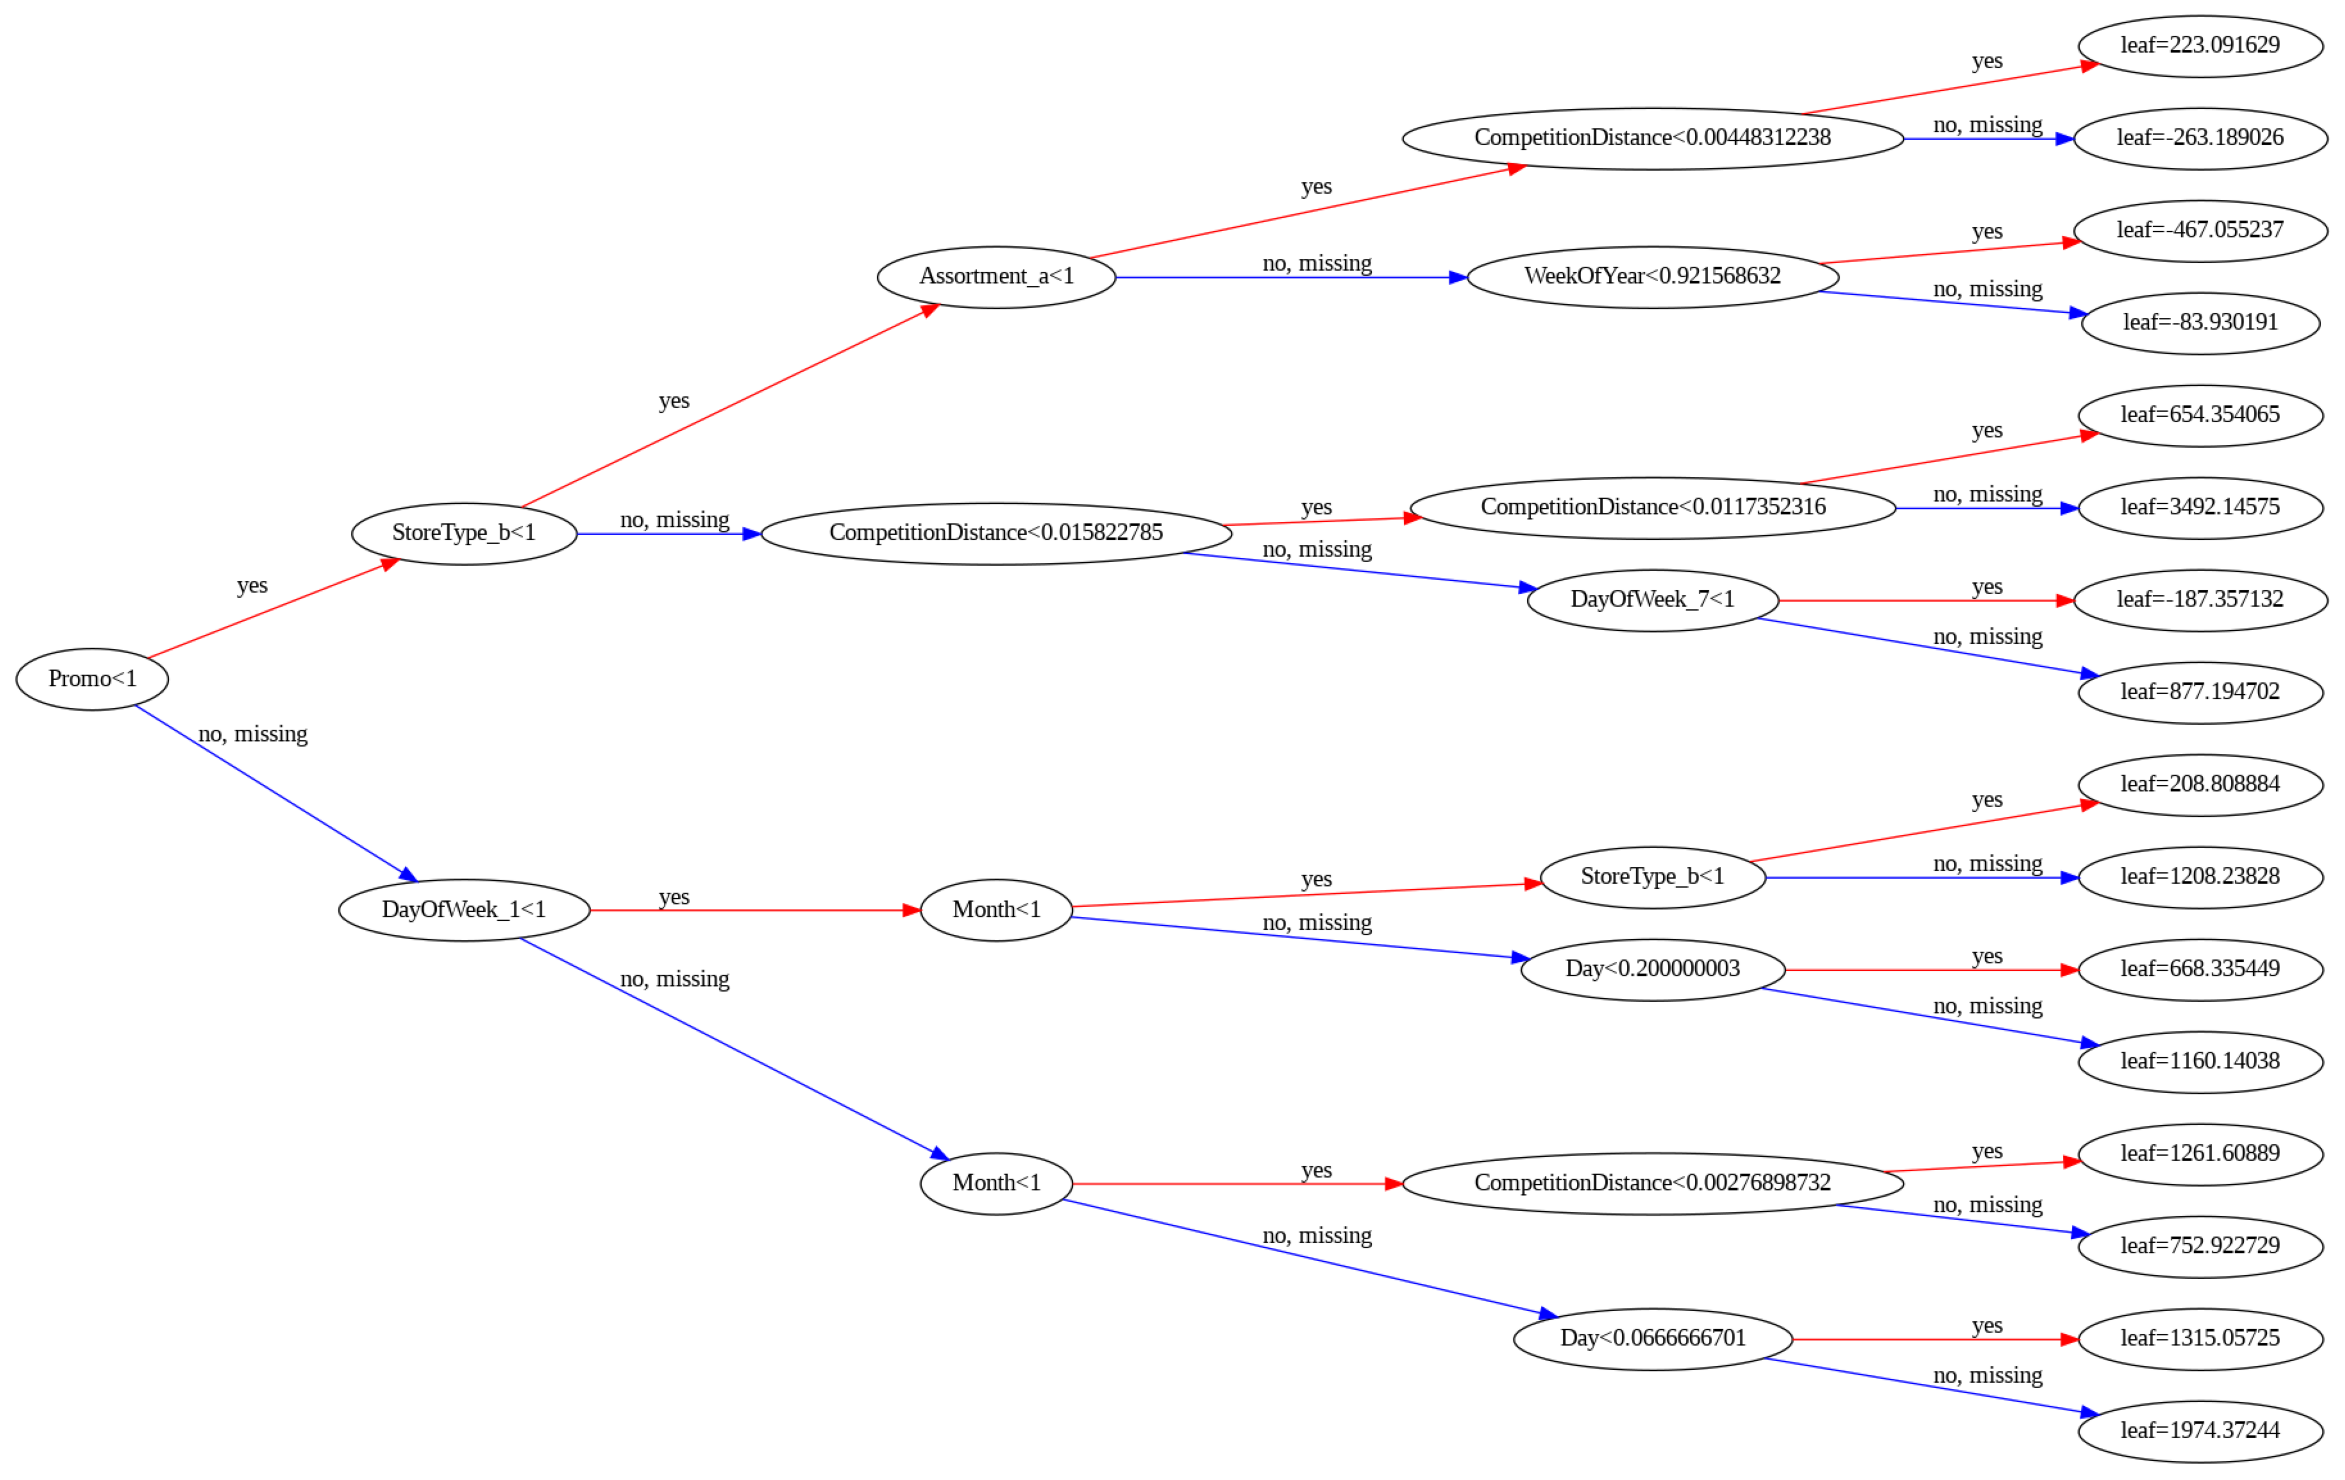

In [123]:
plot_tree(model, rankdir='LR')

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Axes: >

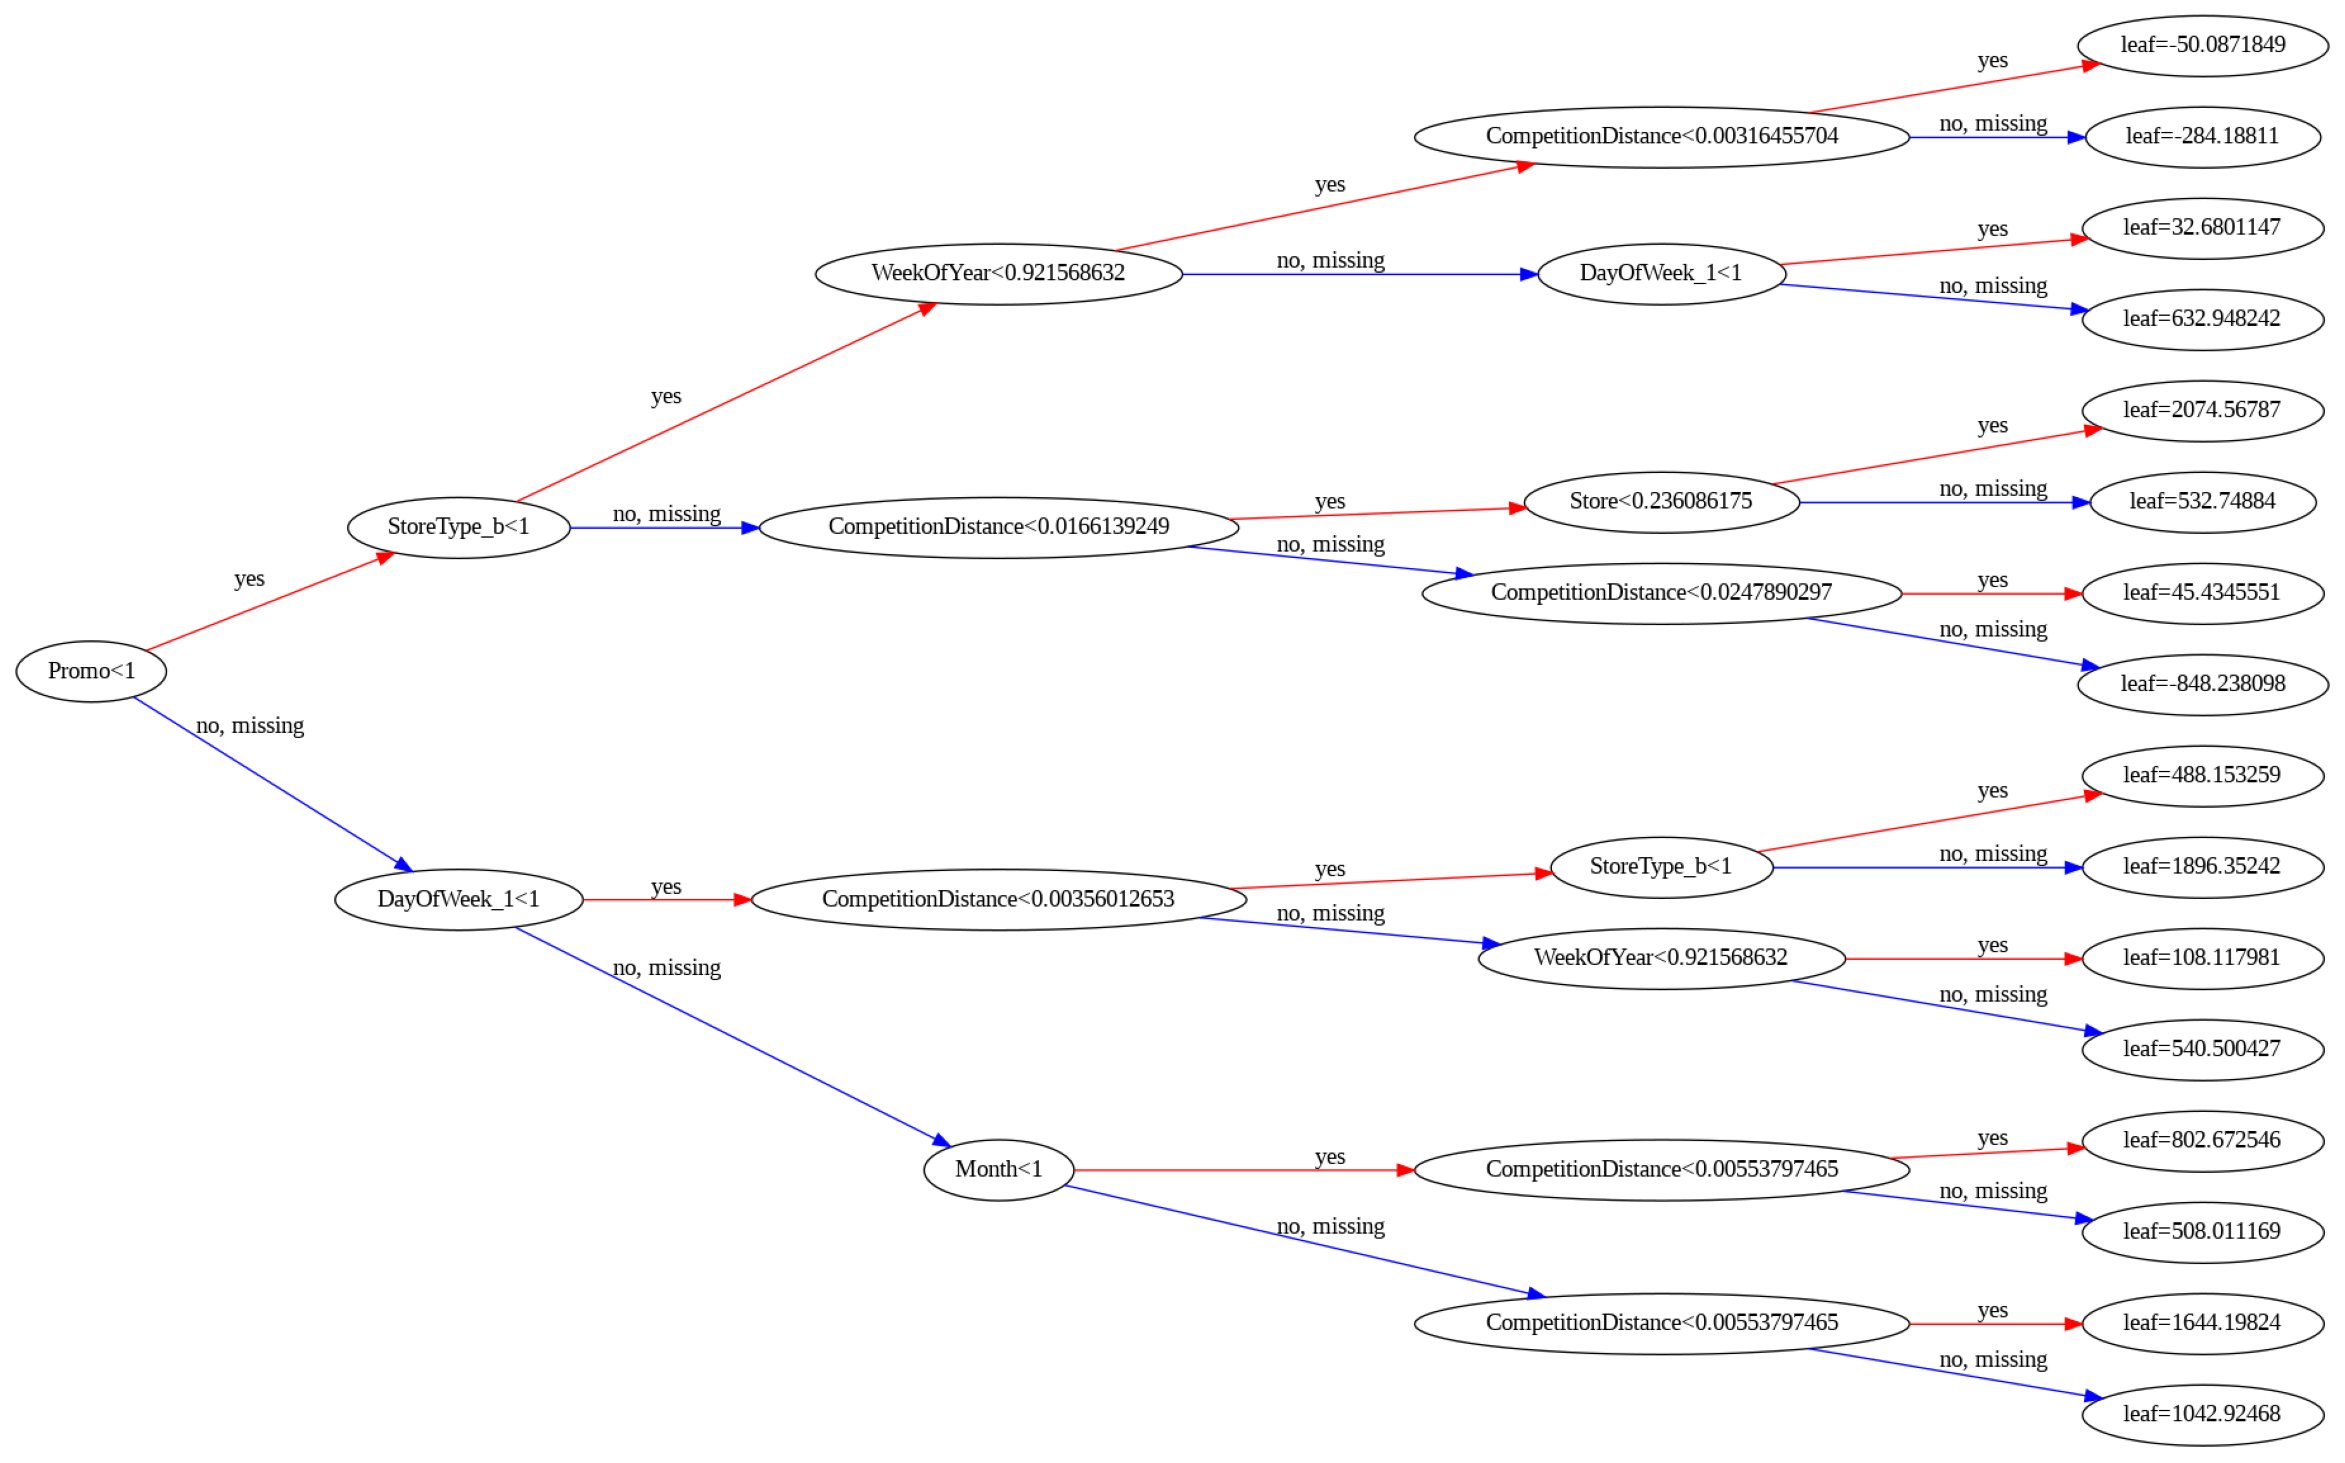

In [124]:
plot_tree(model, rankdir='LR', num_trees=1)

/usr/local/lib/python3.12/dist-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Axes: >

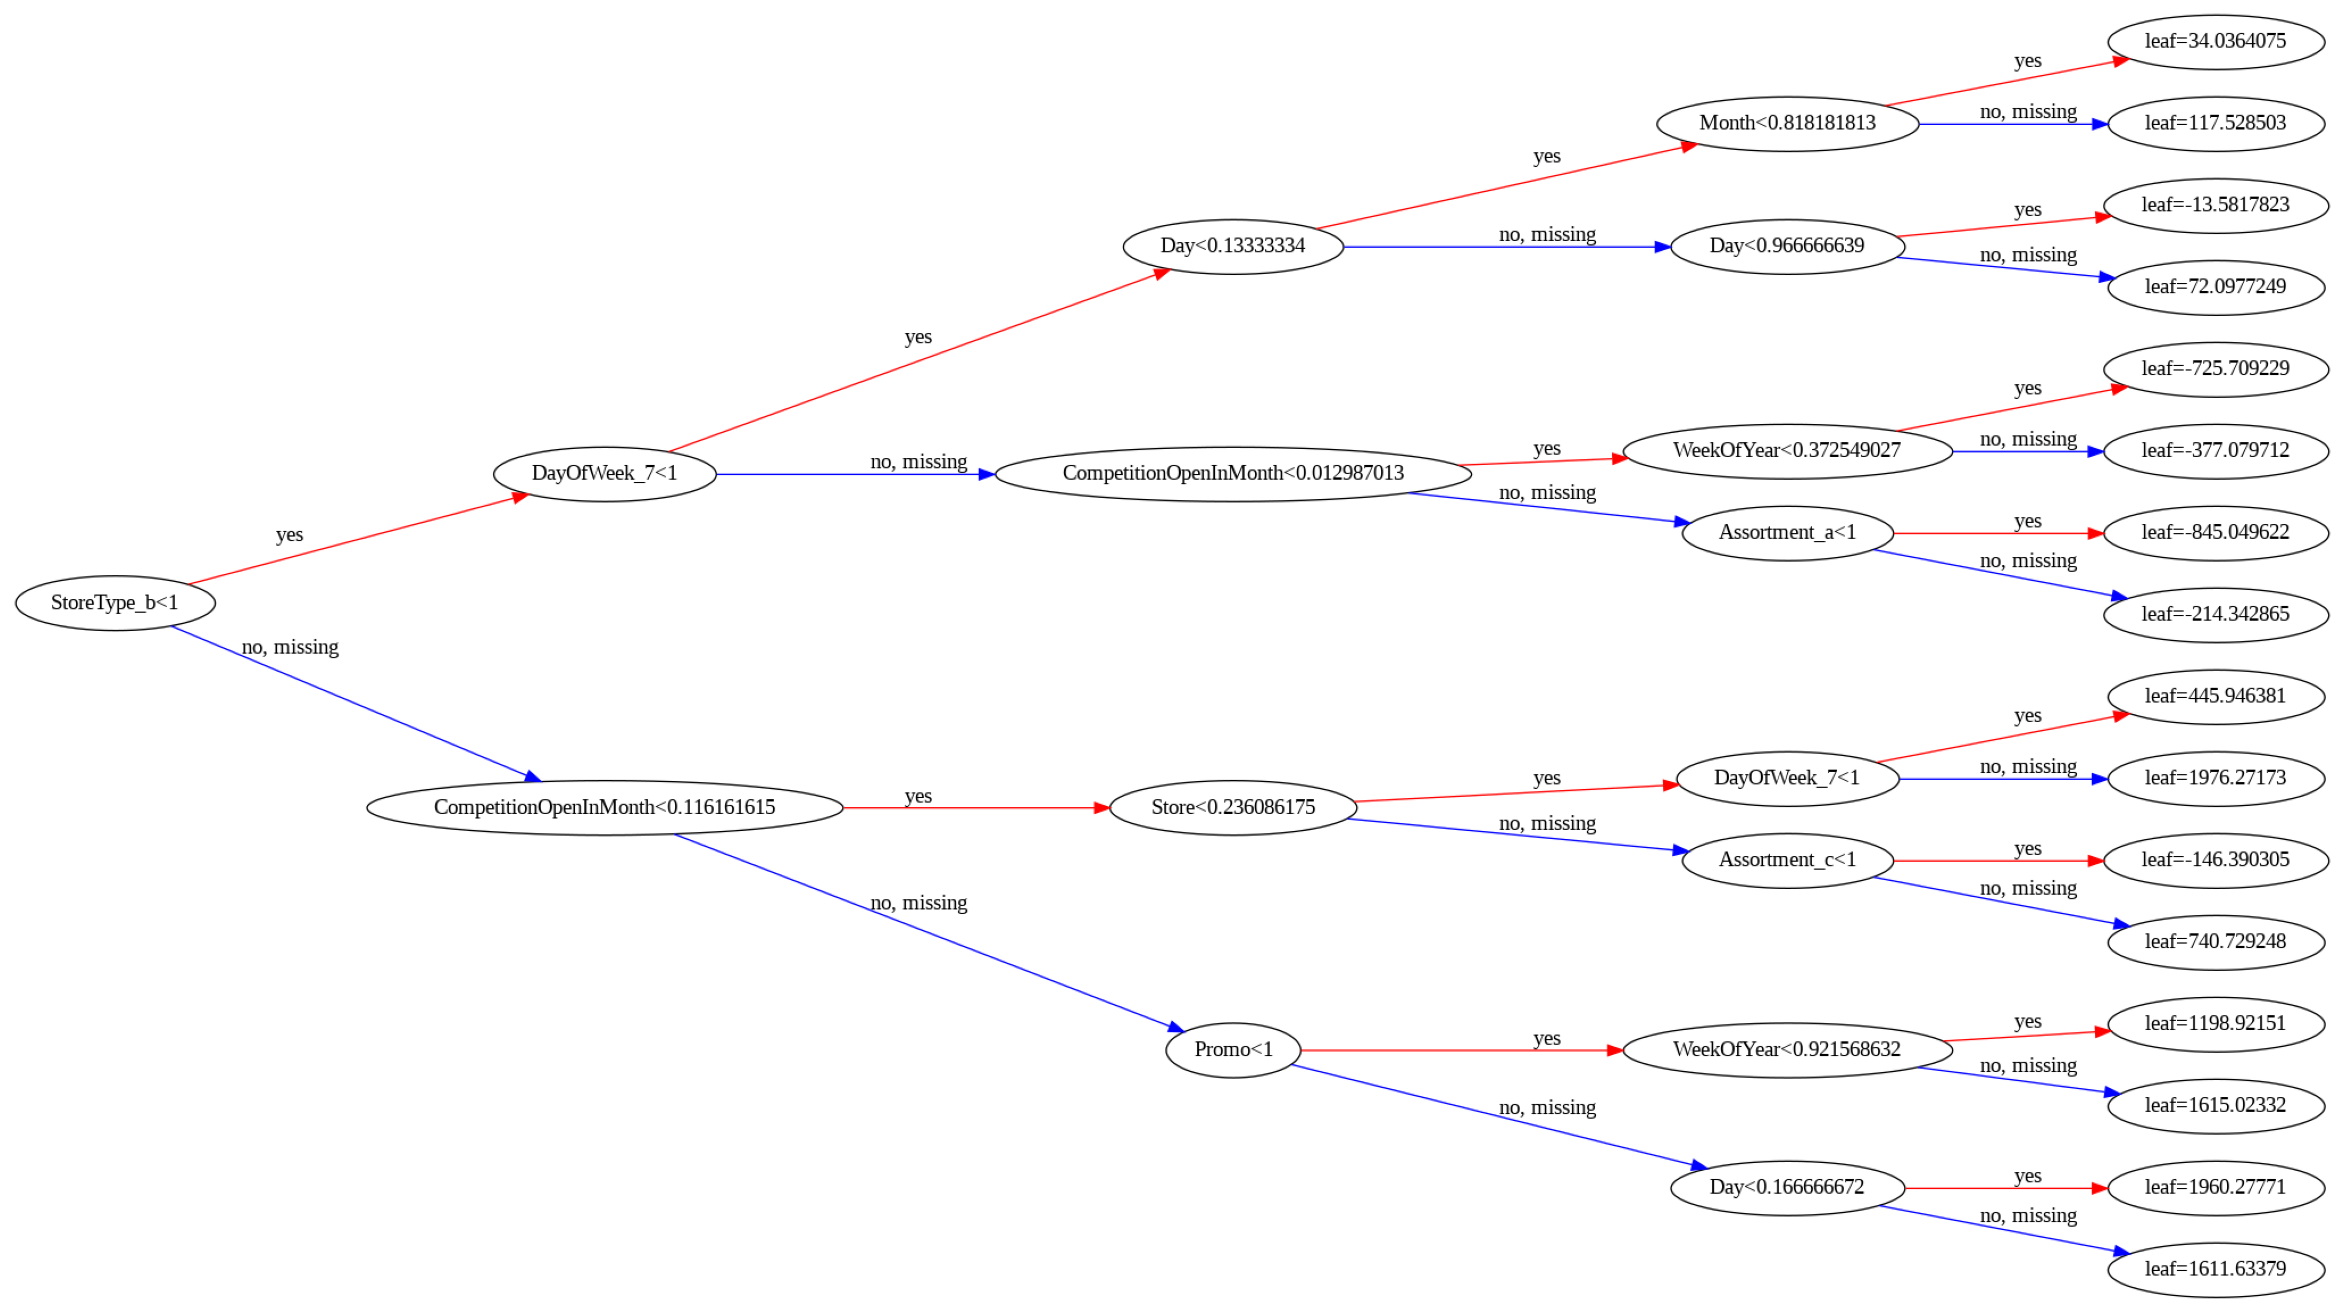

In [125]:
plot_tree(model, rankdir='LR', num_trees=19)

visualize the tree as text

In [126]:
trees = model.get_booster().get_dump()

In [127]:
len(trees)

20

In [128]:
print(trees[0])

0:[Promo<1] yes=1,no=2,missing=2
	1:[StoreType_b<1] yes=3,no=4,missing=4
		3:[Assortment_a<1] yes=7,no=8,missing=8
			7:[CompetitionDistance<0.00448312238] yes=15,no=16,missing=16
				15:leaf=223.091629
				16:leaf=-263.189026
			8:[WeekOfYear<0.921568632] yes=17,no=18,missing=18
				17:leaf=-467.055237
				18:leaf=-83.930191
		4:[CompetitionDistance<0.015822785] yes=9,no=10,missing=10
			9:[CompetitionDistance<0.0117352316] yes=19,no=20,missing=20
				19:leaf=654.354065
				20:leaf=3492.14575
			10:[DayOfWeek_7<1] yes=21,no=22,missing=22
				21:leaf=-187.357132
				22:leaf=877.194702
	2:[DayOfWeek_1<1] yes=5,no=6,missing=6
		5:[Month<1] yes=11,no=12,missing=12
			11:[StoreType_b<1] yes=23,no=24,missing=24
				23:leaf=208.808884
				24:leaf=1208.23828
			12:[Day<0.200000003] yes=25,no=26,missing=26
				25:leaf=668.335449
				26:leaf=1160.14038
		6:[Month<1] yes=13,no=14,missing=14
			13:[CompetitionDistance<0.00276898732] yes=27,no=28,missing=28
				27:leaf=1261.60889
				28:leaf=752.9

## Feature importance
feature importance score

In [129]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

In [131]:
importance_df.head(10)

,feature,importance
1,Promo,0.366149
9,DayOfWeek_1,0.102521
21,StoreType_b,0.061982
8,CompetitionOpenInMonth,0.045616
7,CompetitionDistance,0.045089
24,Assortment_a,0.044878
6,WeekOfYear,0.036306
0,Store,0.034801
23,StoreType_d,0.033262
4,Month,0.031175


<Axes: title={'center': 'feature importance'}, xlabel='importance', ylabel='feature'>

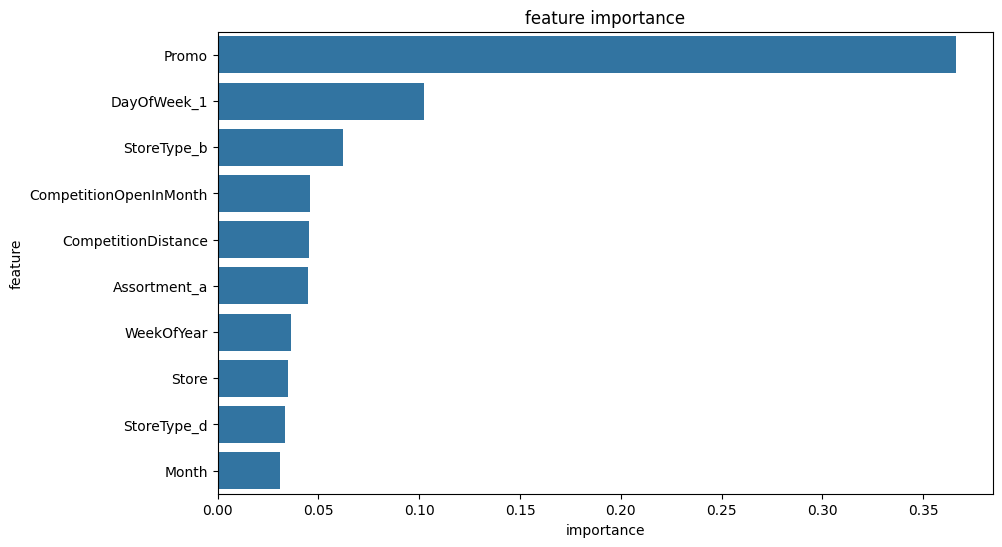

In [132]:
import seaborn as sns
plt.figure(figsize=(10, 6))
plt.title('feature importance')
sns.barplot(data=importance_df.head(10), x='importance', y='feature')
